In [16]:
%%bash
pwd

/home/hugo/Documents/ECAM/26-27/Embed_Sec/Project/notebook


In [25]:
SCOPETYPE='OPENADC'
PLATFORM='CWNANO'
SS_VER='SS_VER_2_1'

%run "../../0.CW-NANO/chipwhisperer/jupyter/Setup_Scripts/Setup_Generic.ipynb"

INFO: Caught exception on reconnecting to target - attempting to reconnect to scope first.
INFO: This is a work-around when USB has died without Python knowing. Ignore errors above this line.
INFO: Found ChipWhisperer😍


Boot message: 
Response: >> ACCESS DENIED

Enter password:



(ChipWhisperer Scope WARNING|File cwnano.py:726) Couldn't read trace data back from Nano


Timeout happened during acquisition


(ChipWhisperer Scope WARNING|File cwnano.py:726) Couldn't read trace data back from Nano


Timeout happened during acquisition


...

(ChipWhisperer Scope WARNING|File cwnano.py:726) Couldn't read trace data back from Nano


Timeout happened during acquisition


(ChipWhisperer Scope WARNING|File cwnano.py:726) Couldn't read trace data back from Nano


Timeout happened during acquisition


KeyboardInterrupt: 

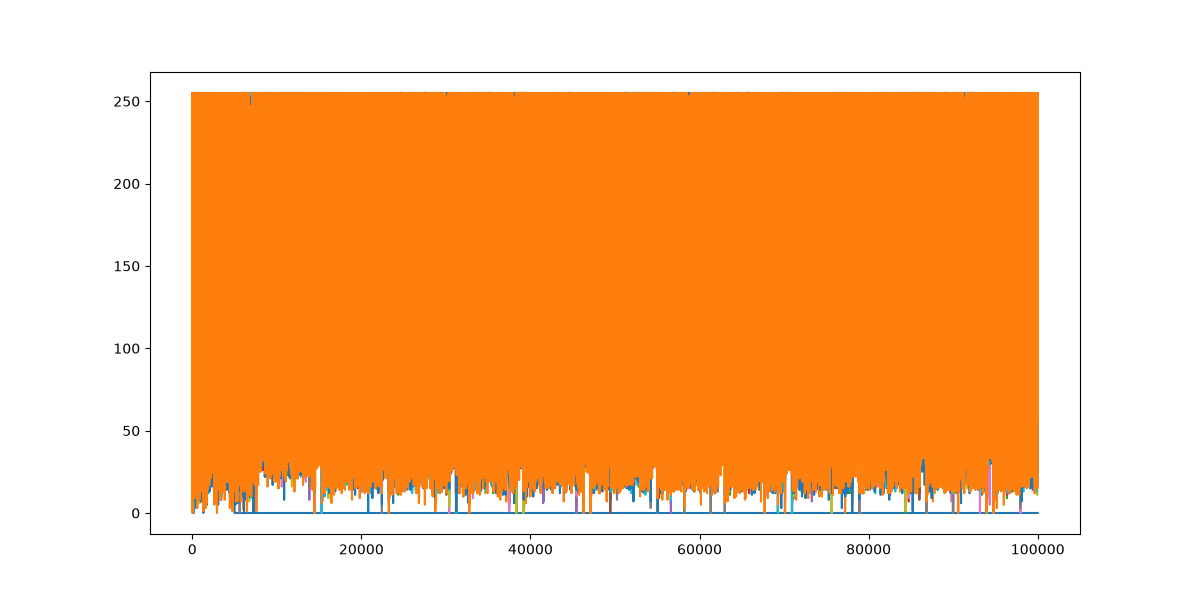

In [26]:
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial2)
target.baud = 9600

# Use the raw serial object, not SimpleSerial parsing
print("Boot message:", target.ser.read(50))   # read up to 50 bytes
 
# Send a wrong password
target.ser.write(b"1234\n")
print("Response:", target.ser.read(50))

def trace_guess(pass_guess):
    reset_target(scope)
    num_char = target.in_waiting()
    while num_char > 0:
        target.read(num_char, 10)
        time.sleep(0.01)
        num_char = target.in_waiting()

    scope.arm()
    scope.adc.samples = 5005000
    target.ser.write(pass_guess.encode() + b'\n')
    #print("Response:", target.ser.read(50))
    ret = scope.capture()
    if ret:
        print('Timeout happened during acquisition')

    trace = scope.get_last_trace()
    return trace

# def cap_pass_trace(pass_guess):
#     reset_target(scope)
#     num_char = target.in_waiting()
#     while num_char > 0:
#         target.read(num_char, 10)
#         time.sleep(0.01)
#         num_char = target.in_waiting()

#     scope.arm()
#     target.ser.write(b'12321')
#     print("Response:", target.ser.read(50))
#     ret = scope.capture()
#     if ret:
#         print('Timeout happened during acquisition')

#     trace = scope.get_last_trace()
#     return trace

# scope.adc.samples = 3000

# trace_test = cap_pass_trace("h\n")

# #Basic sanity check
# assert(len(trace_test) == 3000)
# print("✔️ OK to continue!")

import string
import matplotlib.pyplot as plt
%matplotlib ipympl
LIST_OF_VALID_CHARACTERS = [
    'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
    'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'
]


plt.figure(figsize=(12, 6))

for char in LIST_OF_VALID_CHARACTERS:
    trace = trace_guess(char + "\n")
    plt.plot(trace, label=char)

plt.legend()
plt.show()

In [19]:
ref_trace = trace_guess("C")

fig = cw.plot(ref_trace)

for char in LIST_OF_VALID_CHARACTERS[:12]:
    trace = trace_guess(char + "\n")
    fig *= cw.plot(trace-ref_trace, label=char)


In [20]:
import numpy as np

ref_trace = trace_guess("\x00")[0:100]

for char in LIST_OF_VALID_CHARACTERS:
    trace = trace_guess(char + "\n")[0:100]
    diff = np.sum(np.abs(trace-ref_trace))

    print(f"Character: {char}, Difference: {diff}")

Character: !, Difference: 25.03515625
Character: ", Difference: 27.27734375
Character: #, Difference: 16.8046875
Character: $, Difference: 24.1640625
Character: %, Difference: 28.6015625
Character: &, Difference: 21.50390625
Character: ', Difference: 19.3046875
Character: (, Difference: 31.53515625
Character: ), Difference: 25.96875
Character: *, Difference: 15.2421875
Character: +, Difference: 17.31640625
Character: ,, Difference: 25.765625
Character: -, Difference: 35.203125
Character: ., Difference: 28.28515625
Character: /, Difference: 22.109375
Character: 0, Difference: 29.3359375
Character: 1, Difference: 28.515625
Character: 2, Difference: 12.57421875
Character: 3, Difference: 32.94140625
Character: 4, Difference: 21.80859375
Character: 5, Difference: 21.578125
Character: 6, Difference: 31.8359375
Character: 7, Difference: 27.3125
Character: 8, Difference: 20.80078125
Character: 9, Difference: 28.05078125
Character: :, Difference: 29.8046875
Character: ;, Difference: 18.20703125